In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [4]:
df.head(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


In [5]:
df1 = df.iloc[:,2:]

In [7]:
df1.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


In [16]:
df1.shape

(400, 3)

# Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df1.drop("Purchased", axis=1), df1["Purchased"],  test_size=0.3, random_state=43)

In [15]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [17]:
y_train.shape, y_test.shape

((280,), (120,))

# Standardscaler

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
scaler.fit(X_train)

StandardScaler()

In [21]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
scaler.mean_

array([3.76750000e+01, 7.02678571e+04])

In [24]:
X_train.head()

,Age,EstimatedSalary
265,42,108000
170,21,88000
130,31,58000
314,39,79000
163,35,38000


In [27]:
pd.DataFrame(X_train_scaled).head() # X_train_scaled is numpy array

,0,1
0,0.413155,1.112776
1,-1.592916,0.522947
2,-0.637644,-0.361797
3,0.126574,0.257524
4,-0.255535,-0.951626


In [29]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [30]:
X_train_scaled.head()

,Age,EstimatedSalary
0,0.413155,1.112776
1,-1.592916,0.522947
2,-0.637644,-0.361797
3,0.126574,0.257524
4,-0.255535,-0.951626


In [31]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.675000,70267.857143
std,10.486965,33968.829836
min,18.000000,15000.000000
25%,29.000000,44000.000000
50%,37.000000,70000.000000
75%,46.000000,89000.000000
max,60.000000,150000.000000


In [33]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,-0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,-0.0
75%,0.8,0.6
max,2.1,2.4


# Effect of scaling

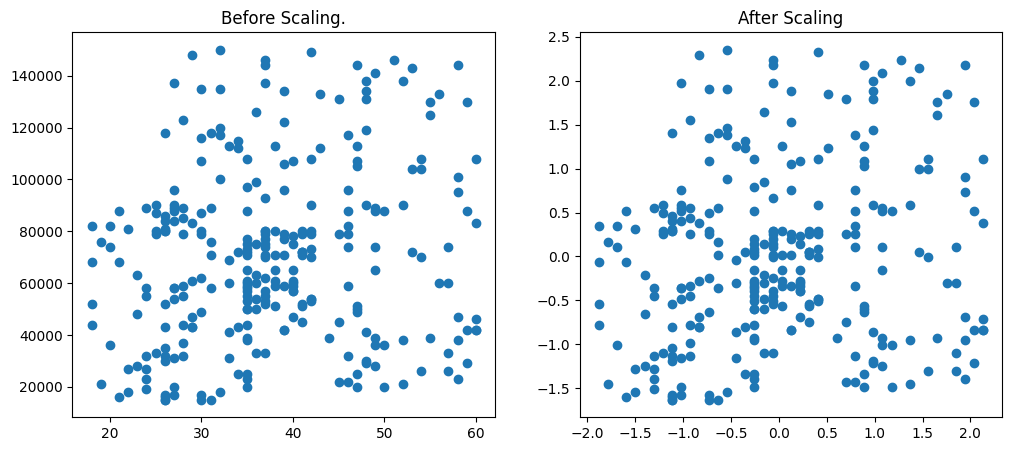

In [38]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))
ax1.scatter(X_train["Age"], X_train["EstimatedSalary"])
ax1.set_title("Before Scaling.")
ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"])
ax2.set_title("After Scaling")
plt.show()

# Comparison of Distributions

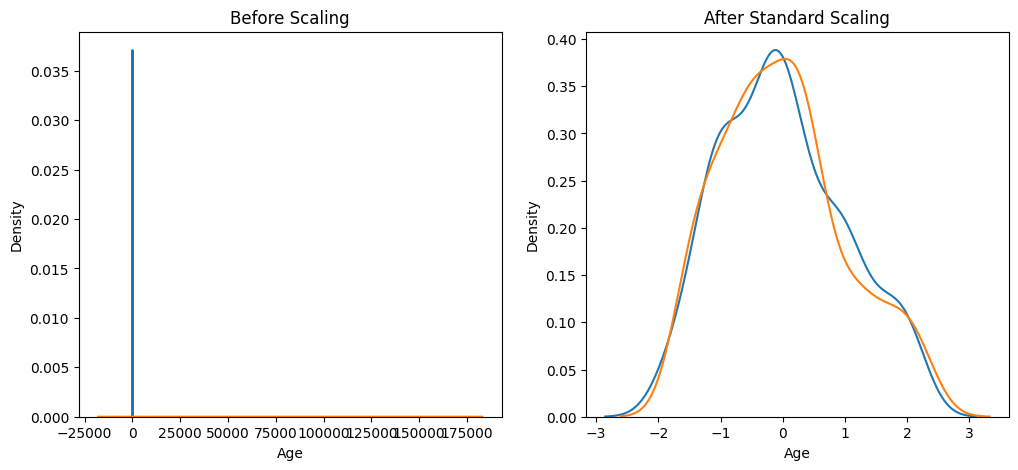

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

ax2.set_title("After Standard Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2)

plt.show()

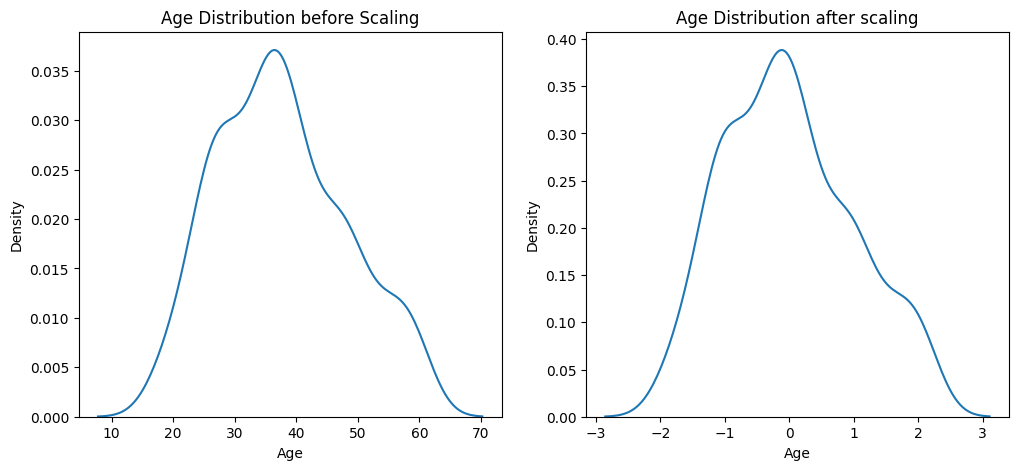

In [55]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Age Distribution before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)

ax2.set_title("Age Distribution after scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2)

plt.show()

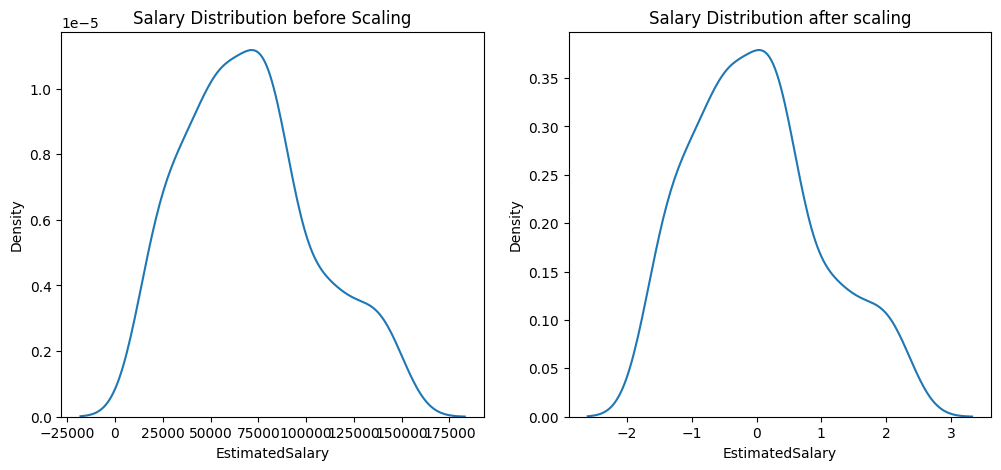

In [57]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Salary Distribution before Scaling")
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

ax2.set_title("Salary Distribution after scaling")
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2)

plt.show()

# Why Scaling is important?

In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [61]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [62]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [65]:
from sklearn.metrics import accuracy_score

In [67]:
print("Actual data :", accuracy_score(y_test, y_pred) )
print("Scaled data :", accuracy_score(y_test, y_pred_scaled))

Actual data : 0.7833333333333333
Scaled data : 0.7916666666666666


In [70]:
# there are some algorithm where, there is no effect of scaling like eg. decision tree.
from sklearn.tree import DecisionTreeClassifier

In [71]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [72]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [73]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [77]:
print("Actual data :", np.round(accuracy_score(y_test, y_pred) ,2))
print("Scaled data :", accuracy_score(y_test, y_pred_scaled))

Actual data : 0.84
Scaled data : 0.85


# Effect of Outlier

In [80]:
df1 = df1._append(pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]}),ignore_index=True)

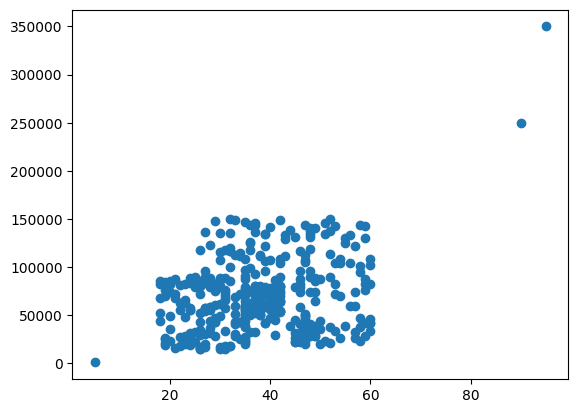

In [81]:
plt.scatter(df1['Age'], df1['EstimatedSalary'])

In [82]:
X_train, X_test, y_train, y_test = train_test_split(df1.drop('Purchased', axis=1),df1['Purchased'],test_size=0.3,random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [83]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

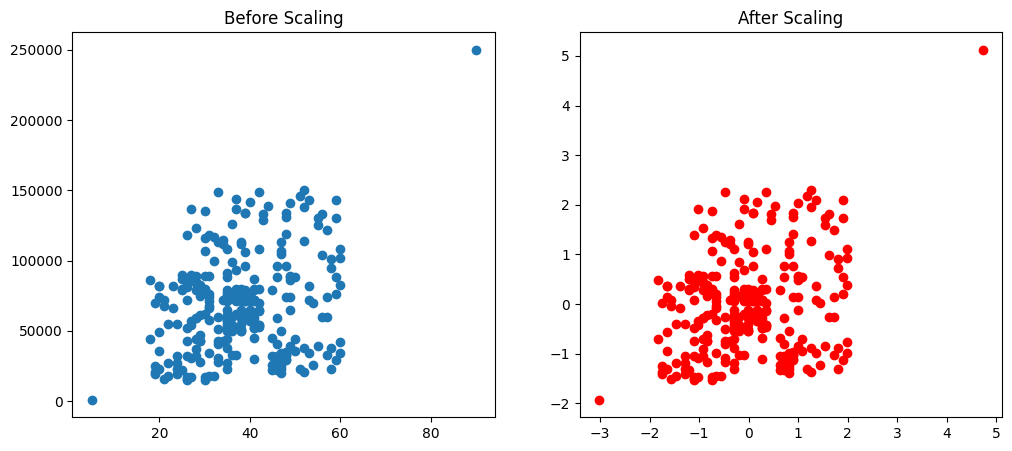

In [85]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

In [86]:
# From this we can conclude that outliers are the sane after scaling so we have to remove the outliers.

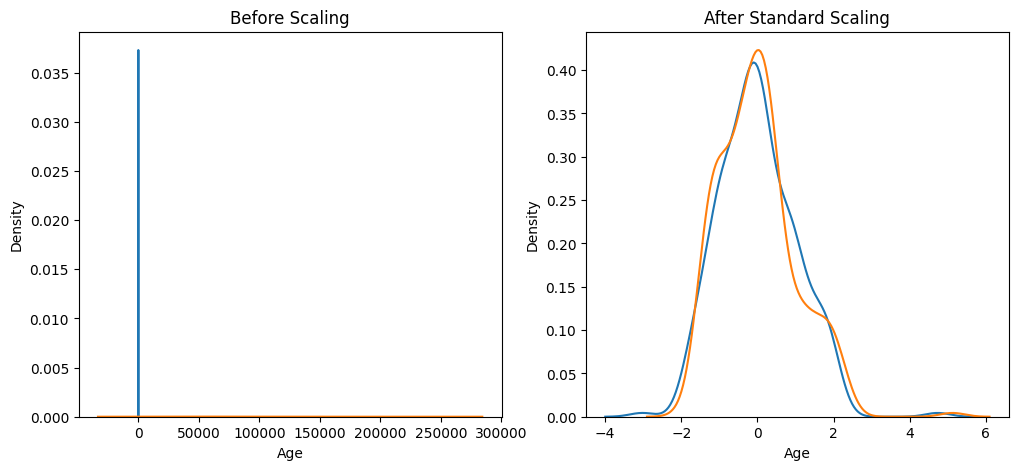

In [87]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train["Age"], ax=ax1)
sns.kdeplot(X_train["EstimatedSalary"], ax=ax1)

ax2.set_title("After Standard Scaling")
sns.kdeplot(X_train_scaled["Age"], ax=ax2)
sns.kdeplot(X_train_scaled["EstimatedSalary"], ax=ax2)

plt.show()